Bir nörona giren değerlerin “w” değerleriyle çarpılıp toplandığını (dot-product) ve sonuca bias değerinin toplanarak aktivasyon fonksiyonuna sokulduğunu biliyoruz. Örneğin modelin girdi katmanında x1, x2 ve x3 olmak üzere üç “sütun (feature)” bulunuyor olsun.
Bu girdiler ilk saklı katmana sokulduğunda w1 x1 + w2 x2 + w3 x3 + bias biçiminde bir işleme girecektir. Bu işlemin sonucu da aktivasyon fonksiyonuna sokulacaktır. İşte bu dot-product işleminde x1, x2, x3 sütunlarının mertebeleri birbirlerinden çok farklıysa mertebesi yüksek olan sütunun dot-product etkisi yüksek olacaktır. Bu durum da sanki o sütunun daha önemli olarak değerlendirilmesine yol açacaktır. Bu biçimdeki bir sinir ağı “geç yakınsar” ve kestirim bakımından zayıflar. İşte bu nedenden dolayı işin başında sütunların (yani özelliklerin) mertebelerini birbirlerine yaklaştırmak gerekmektedir. Bu işlemlere “özellik ölçeklemesi (feature scaling)” denilmektedir. Yapay sinir ağlarında sütunlar arasında mertebe farklılıkları varsa mutlaka özellik ölçeklemesi yapılmalıdır.
Özellik ölçeklemesi makine öğrenmesinde başka konularda da gerekebilmektedir. Ancak bazı konularda gerekmemektedir. Biz kursumuzda her konuda özellik ölçeklemesinin gerekli olup olmadığını açıklayacağız.

Çeşitli özellik ölçekleme yöntemleri vardır. En çok kullanılan iki yöntem "standart ölçekleme (standard scaling)" ve "minmax ölçekleme (minmax scaling)"dir. Özellik ölçeklemesi konusunda aşağıdaki sorular sıkça sorulmaktadır:

Soru: Yapay sinir ağlarında özellik ölçeklemesi her zaman gerekir mi?
Cevap: Eğer sütunlar metre cinsinden ve birbirlerine zaten yakınsa, özellik ölçeklemesi yapılmayabilir.

Soru: Özellik ölçeklemesi gerektiği halde yapmazsak ne olur?
Cevap: Modelin kestirim gücü azalır. Yani performansı düşer.

Soru: Özellik ölçeklemesi gerekmediği halde özellik ölçeklemesi yaparsak bunun bir zararı dokunur mu?
Cevap: Hayır, dokunmaz.

Soru: Kategorik sütunlara (0 ve 1’lerden oluşan ya da one-hot encoding yapılmış) özellik ölçeklemesi uygulayabilir miyiz?
Cevap: Bu sütunlara özellik ölçeklemesi uygulanmayabilir. Ancak uygulamanın bir sakıncası olmaz. Genellikle veri bilimcileri tüm sütunlara özellik ölçeklemesi uyguladıkları için bunlara da uygularlar.

Özellik ölçeklemesi X verilerine uygulanmalıdır; Y verilerine uygulanmasının genel olarak faydası yoktur.
Ayrıca bir nokta önemlidir: Biz ağımızı nasıl eğittiysek öyle test ve kestirim yapmalıyız. Yani eğer özellik ölçeklemesi yaptıysak, bu işlemden önce test verilerini de kestirim verilerini de önce ölçeklendirip sonra işleme sokmalıyız.

En çok kullanılan özellik ölçeklendirme yöntemlerinden biri "standart ölçekleme (standard scaling)" yöntemidir. Bu yöntemde sütunlar diğerlerinden bağımsız olarak kendi aralarında standart normal dağılıma uydurulmaktadır. Bu işlem şöyle yapılmaktadır:

(x - mean(x)) / std(x)

Tabii burada biz formülü pseudo kod (sözde kod) olarak verdik. Buradaki mean sütunun ortalamasını, std ise standart sapmasını belirtmektedir.
Bir sütunu bu biçimde ölçeklendirdiğimizde, değerler büyük ölçüde 0'ın etrafında toplanır.

Standart ölçekleme yapan bir fonksiyonu şöyle yazabiliriz:

In [3]:
import numpy as np

def standart_scaler(dataset):
    result = np.zeros(dataset.shape)
    for col in range(dataset.shape[1]):
        result[:, col] = (dataset[:, col] - np.mean(dataset[:, col])) / np.std(dataset[:, col])
    return result

a = np.array([[12, 20, 9], [2, 5, 6], [4, 8, 9]])

result = standart_scaler(a)
print(a, end='\n\n')
print(result)

[[12 20  9]
 [ 2  5  6]
 [ 4  8  9]]

[[ 1.38873015  1.38873015  0.70710678]
 [-0.9258201  -0.9258201  -1.41421356]
 [-0.46291005 -0.46291005  0.70710678]]


Aslında yukarıdaki fonksiyon `axis=0` için tek hamlede de yapılabilir.

---

```python
import numpy as np

def standard_scaler(dataset):
    return (dataset - np.mean(dataset, axis=0)) / np.std(dataset, axis=0)

a = np.array([[12, 20, 9], 
              [2, 5, 6], 
              [4, 8, 9]])

result = standard_scaler(a)
print(a, end='\n\n')
print(result)

Aslında scikit-learn içerisinde zaten standart ölçekleme yapan bir fonksiyon vardır. Standart Scaler veri kümesinde sütunların kendi aralarında normal dağılıp yapması durumunda kullanılır. Bunu kontrol etmek için histogram çizilir.

In [4]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(a)

result2 = ss.transform(a)
print(result2)

[[ 1.38873015  1.38873015  0.70710678]
 [-0.9258201  -0.9258201  -1.41421356]
 [-0.46291005 -0.46291005  0.70710678]]


Örneğin "diabetes.csv" veri kümesi üzerinde standart ölçekleme yapmak isteyelim. Bunun için önce veri kümesini dataset_x ve dataset_y biçiminde ayırmamız gerekir. Ondan sonra biz veri kümesini "eğitim" ve "test" olmak üzere ikiye ayırabiliriz. Ondan sonra eğitim veri kümesi üzerinde özellik ölçeklemesi yapıp eğitimi uygulayabiliriz. Yani ölçekleme işlemi genel olarak train_test_split işleminden sonra yapılmaktadır. Burada elde edilen ölçekleme bilgisinin test işlemi öncesinde test veri kümesine de, kestirim işlemi öncesinde kestirim veri kümesine de uygulanması gerekmektedir.

Model: "Diabetes"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Hidden-1 (Dense)            (None, 64)                576       
                                                                 
 Hidden-2 (Dense)            (None, 64)                4160      
                                                                 
 Output (Dense)              (None, 1)                 65        
                                                                 
Total params: 4801 (18.75 KB)
Trainable params: 4801 (18.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/100
16/16 [==============================] - 1s 12ms/step - loss: 0.6360 - binary_accuracy: 0.6619 - val_loss: 0.6119 - val_binary_accuracy: 0.6992
Epoch 2/100
16/16 [==============================] - 0s 4ms/step - loss: 0.5397 - binary_accuracy: 0.7739 - val_loss: 0.5717 - val_b

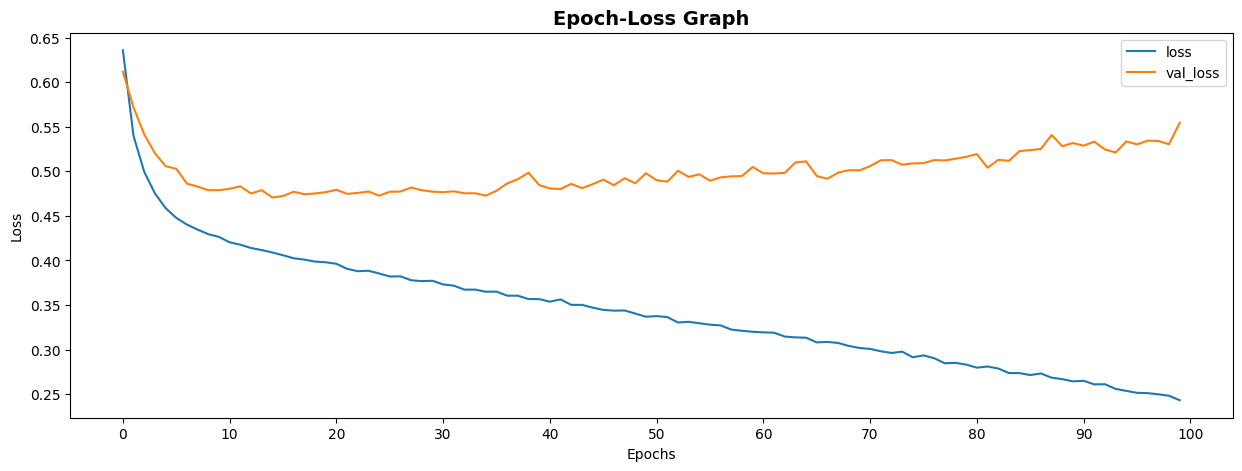

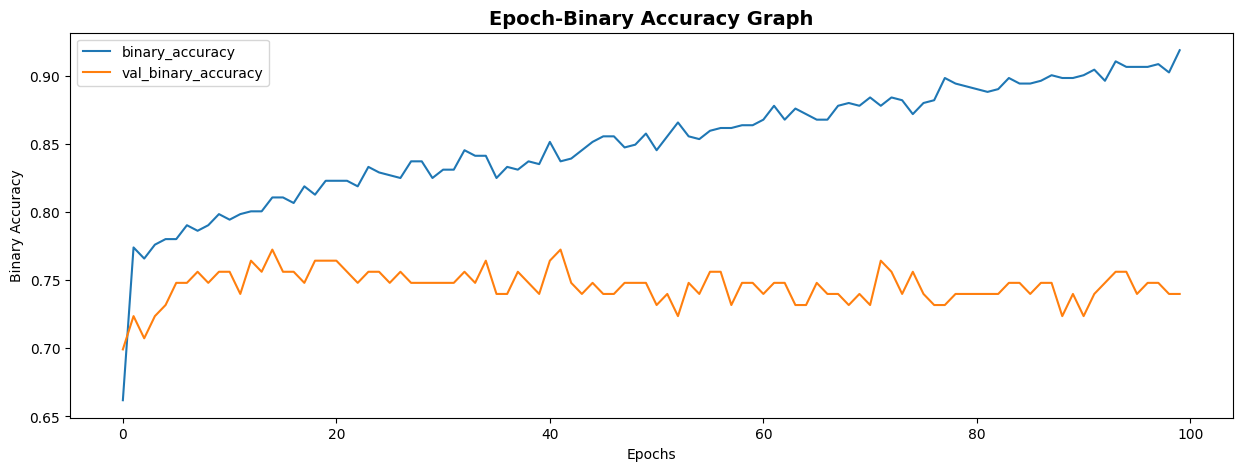

In [13]:
import pandas as pd 

df = pd.read_csv('datasets/diabetes.csv')

dataset_x = df.iloc[:, :-1].to_numpy()
dataset_y = df.iloc[:, -1].to_numpy()

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

training_dataset_x, test_dataset_x, training_dataset_y, test_dataset_y = train_test_split(dataset_x, dataset_y, test_size=0.2, random_state=42)

ss = StandardScaler()
ss.fit(training_dataset_x)

transformed_training_dataset_x = ss.transform(training_dataset_x)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential(name='Diabetes')
model.add(Dense(64, activation='relu', input_dim=dataset_x.shape[1], name='Hidden-1'))
model.add(Dense(64, activation='relu', name='Hidden-2'))
model.add(Dense(1, activation='sigmoid', name='Output'))

model.summary()

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['binary_accuracy'])

hist = model.fit(transformed_training_dataset_x, training_dataset_y, batch_size=32, epochs=100, validation_split=0.2)

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.title('Epoch-Loss Graph', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(range(0, 210, 10))

plt.plot(hist.epoch, hist.history['loss'])
plt.plot(hist.epoch, hist.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.show()

plt.figure(figsize=(15, 5))
plt.title('Epoch-Binary Accuracy Graph', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Binary Accuracy')
# plt.xticks(range(0, 210, 10))

plt.plot(hist.epoch, hist.history['binary_accuracy'])
plt.plot(hist.epoch, hist.history['val_binary_accuracy'])
plt.legend(['binary_accuracy', 'val_binary_accuracy'])
plt.show()

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

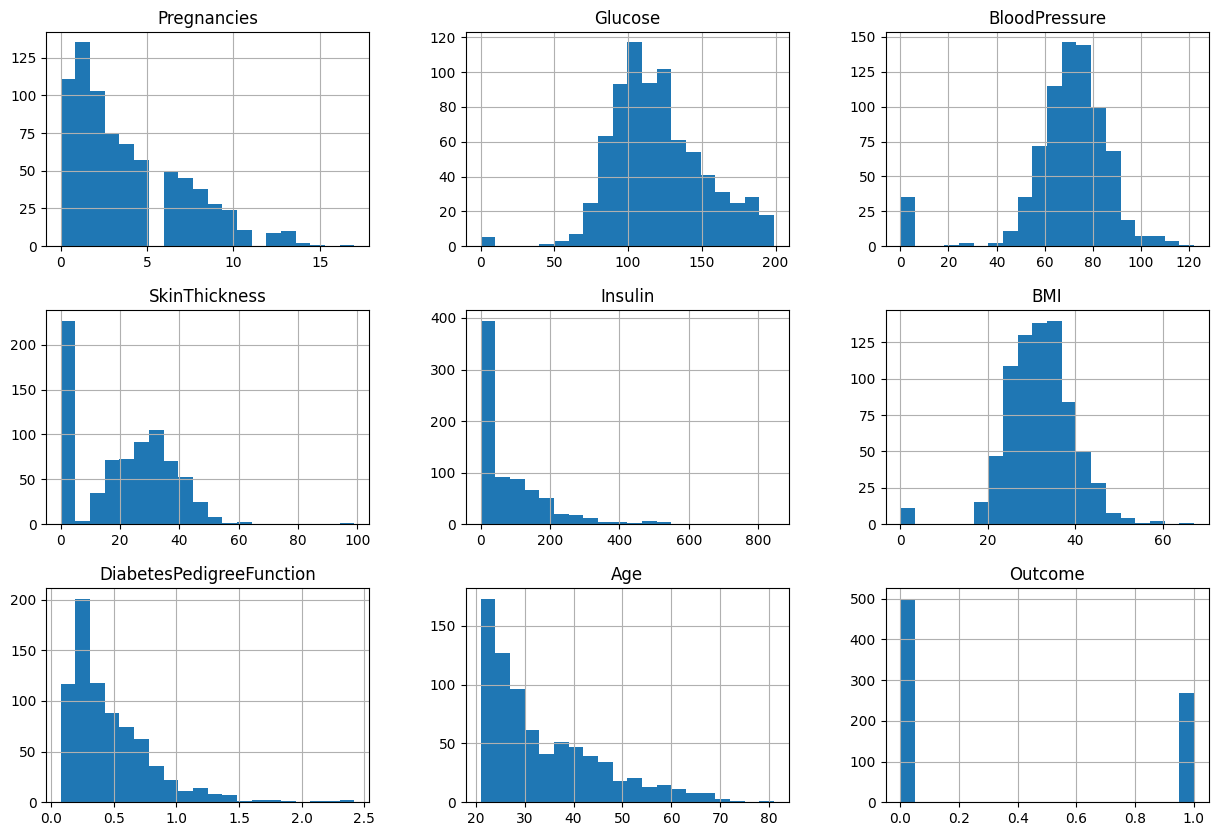

In [14]:
df.hist(figsize=(15, 10), bins=20, grid=True)

In [15]:
transformed_test_dataset_x = ss.transform(test_dataset_x)

eval_result = model.evaluate(transformed_test_dataset_x, test_dataset_y, batch_size=32)

for i in range(len(model.metrics_names)):
    print(f'{model.metrics_names[i]}: {eval_result[i]}')

5/5 [==============================] - 0s 2ms/step - loss: 0.7682 - binary_accuracy: 0.7468
loss: 0.7682417631149292
binary_accuracy: 0.7467532753944397


In [16]:
predict_data = np.array([[2,148,58,37,128,25.4,0.699,24], [7,114,67,0,0,32.8,0.258,42],
                         [5,99,79,27,0,29.0,0.203,32], [0,110,85,30,0,39.5,0.855,39]])

transformed_predict_data = ss.transform(predict_data)
predict_result = model.predict(transformed_predict_data)

for i in range(len(predict_result)):
    print(predict_result[i, 0])

for i in range(len(predict_result)):
    print("Şeker Hastası" if predict_result[i, 0] > 0.5 else "Şeker Hastası Değil")


1/1 [==============================] - 0s 101ms/step
0.44016778
0.4305034
0.053412285
0.8518378
Şeker Hastası Değil
Şeker Hastası Değil
Şeker Hastası Değil
Şeker Hastası


### Min-Max Ölçeklemesi [0, 1]

Genelde bu kullanılır.

In [2]:
import numpy as np

a = np.array([[12, 20, 9], [2, 5, 6], [4, 8, 9]])

from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()

mms.fit(a) 
result = mms.transform(a)
print(result)

[[1.  1.  1. ]
 [0.  0.  0. ]
 [0.2 0.2 1. ]]


### Max ABS Ölçeklemesi


In [3]:
from sklearn.preprocessing import MaxAbsScaler

mas = MaxAbsScaler()
mas.fit(a)
result = mas.transform(a)
print(result)

[[1.         1.         1.        ]
 [0.16666667 0.25       0.66666667]
 [0.33333333 0.4        1.        ]]


#### Özellik ölçeklemesi yapılan modelin kayıt edilmesi



Model: "Diabetes"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Hidden-1 (Dense)            (None, 64)                576       
                                                                 
 Hidden-2 (Dense)            (None, 64)                4160      
                                                                 
 Output (Dense)              (None, 1)                 65        
                                                                 
Total params: 4801 (18.75 KB)
Trainable params: 4801 (18.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

Epoch 1/100


16/16 [==============================] - 1s 12ms/step - loss: 0.6710 - binary_accuracy: 0.6415 - val_loss: 0.6769 - val_binary_accuracy: 0.6098
Epoch 2/100
16/16 [==============================] - 0s 3ms/step - loss: 0.6550 - binary_accuracy: 0.6640 - val_loss: 0.6703 - 

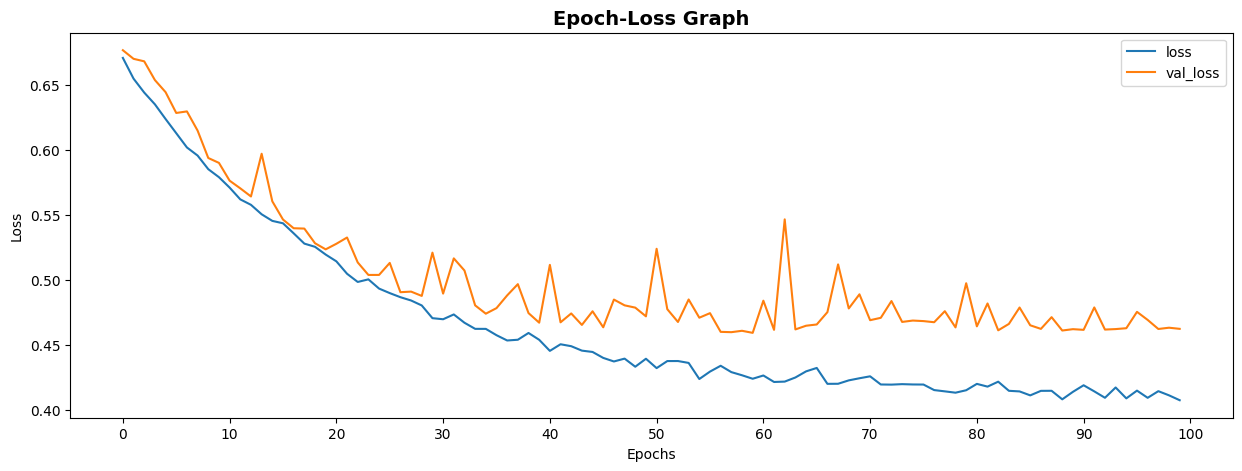

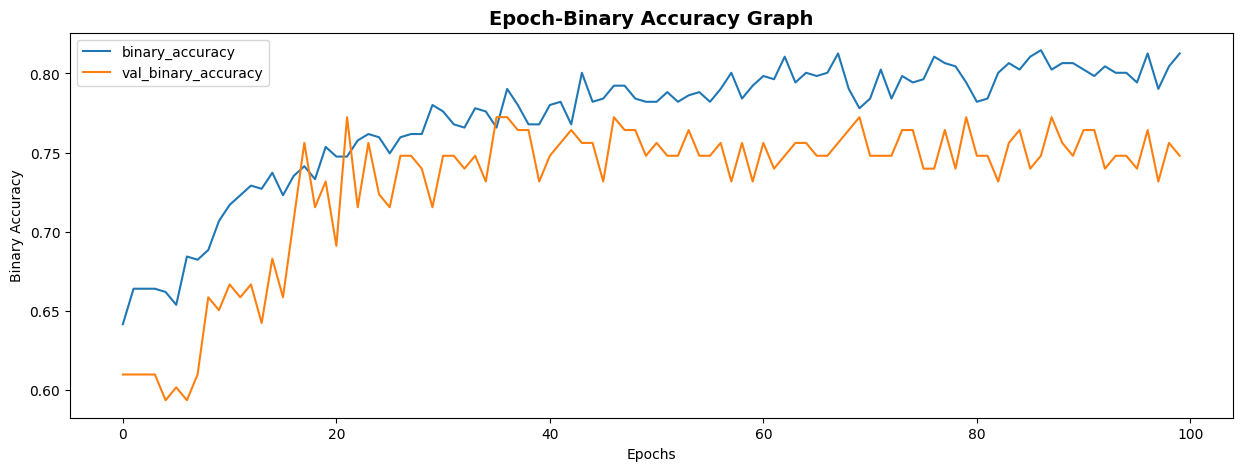

5/5 [==============================] - 0s 2ms/step - loss: 0.5400 - binary_accuracy: 0.7403


c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [4]:
import pandas as pd 

df = pd.read_csv('datasets/diabetes.csv')

dataset_x = df.iloc[:, :-1].to_numpy()
dataset_y = df.iloc[:, -1].to_numpy()

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

training_dataset_x, test_dataset_x, training_dataset_y, test_dataset_y = train_test_split(dataset_x, dataset_y, test_size=0.2, random_state=42)

mms = MinMaxScaler()
mms.fit(training_dataset_x)

transformed_training_dataset_x = mms.transform(training_dataset_x)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential(name='Diabetes')
model.add(Dense(64, activation='relu', input_dim=dataset_x.shape[1], name='Hidden-1'))
model.add(Dense(64, activation='relu', name='Hidden-2'))
model.add(Dense(1, activation='sigmoid', name='Output'))

model.summary()

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['binary_accuracy'])

hist = model.fit(transformed_training_dataset_x, training_dataset_y, batch_size=32, epochs=100, validation_split=0.2)

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.title('Epoch-Loss Graph', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(range(0, 210, 10))

plt.plot(hist.epoch, hist.history['loss'])
plt.plot(hist.epoch, hist.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.show()

plt.figure(figsize=(15, 5))
plt.title('Epoch-Binary Accuracy Graph', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Binary Accuracy')
# plt.xticks(range(0, 210, 10))

plt.plot(hist.epoch, hist.history['binary_accuracy'])
plt.plot(hist.epoch, hist.history['val_binary_accuracy'])
plt.legend(['binary_accuracy', 'val_binary_accuracy'])
plt.show()

transformed_test_dataset_x = mms.transform(test_dataset_x)

eval_result = model.evaluate(transformed_test_dataset_x, test_dataset_y, batch_size=32)

model.save('diabetes_model.h5')

import pickle

with open('diabetes_model.pickle', 'wb') as file:
    pickle.dump(mms, file)

In [5]:
from tensorflow.keras.models import load_model

load_model('diabetes_model.h5')

import pickle

with open('diabetes_model.pickle', 'rb') as file:
    mms_loaded = pickle.load(file)
    
import numpy as np

predict_data = np.array([[2,148,58,37,128,25.4,0.699,24], [7,114,67,0,0,32.8,0.258,42],
                         [5,99,79,27,0,29.0,0.203,32], [0,110,85,30,0,39.5,0.855,39]])

transformed_predict_data = mms_loaded.transform(predict_data)
predict_result = model.predict(transformed_predict_data)

for i in range(len(predict_result)):
    print(predict_result[i, 0])

for i in range(len(predict_result)):
    print("Şeker Hastası" if predict_result[i, 0] > 0.5 else "Şeker Hastası Değil")


1/1 [==============================] - 0s 76ms/step
0.45617744
0.2919739
0.10135759
0.7307228
Şeker Hastası Değil
Şeker Hastası Değil
Şeker Hastası Değil
Şeker Hastası
